# NHL Road Fatigue Analysis
## Utah Mammoth — 2024/25 & 2025/26 Seasons

**Published:** April 28, 2026  
**Data source:** NHL Public API (`api-web.nhle.com`)  
**Method:** Road Trip Decay Index

---

### What this notebook covers

1. Setup and data fetching utilities
2. League standings overview
3. Utah Mammoth roster
4. Schedule analysis — travel burden and back-to-backs
5. Clayton Keller — fatigue signals across a full season
6. Back-to-back splits across the full Utah roster
7. Road Trip Decay Index — full roster analysis
8. Logan Cooley — peer group comparison (12 comparable young players)
9. Logan Cooley — season arc analysis (2024/25)
10. Year-over-year comparison (2024/25 vs. 2025/26)
11. Logan Cooley — injury-adjusted 2025/26 analysis
12. Key findings and playoff implications

---

### The core metric

**Road Trip Decay Index** = pts/gm (Road Game 3+) − pts/gm (Road Game 1)

A score of 0.00 means no drop-off. Negative means the player fades deep in trips. Positive means they actually get better.

Minimum 3 qualifying deep road games required for inclusion.

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, '/Users/michaelharman/Projects/NHL/NHL_Fatigue')
sys.path.insert(0, '/Users/michaelharman/Projects/NHL/NHL_Fatigue/src')

import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from nhl_client import (
    get_teams, get_roster, get_team_schedule, get_player_game_log
)
from schedule_analysis import build_schedule_features, summarise_travel_burden

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.2f}'.format)

TEAM        = 'UTA'
SEASON_2425 = '20242025'
SEASON_2526 = '20252026'

# Plot styling
plt.rcParams['figure.facecolor'] = '#0e0f12'
plt.rcParams['axes.facecolor']   = '#13151a'
plt.rcParams['axes.edgecolor']   = '#2a2a32'
plt.rcParams['axes.labelcolor']  = '#888'
plt.rcParams['xtick.color']      = '#888'
plt.rcParams['ytick.color']      = '#888'
plt.rcParams['text.color']       = '#e8e8e8'
plt.rcParams['grid.color']       = '#1e2028'
plt.rcParams['grid.linewidth']   = 0.5

LAVENDER = '#DDDBF1'
NAVY     = '#3C4F76'
SAND     = '#D1BEB0'
GREEN    = '#3ecf8e'
RED      = '#e07070'
AMBER    = '#c9a55e'

print('Setup complete.')

Setup complete.


---
## 2. League standings

In [2]:
standings = get_teams()
print(f'{len(standings)} teams')
standings.sort_values('points', ascending=False)

32 teams


,team_abbr,team_name,conference,division,wins,losses,points
0,COL,Colorado Avalanche,Western,Central,55,16,121
1,CAR,Carolina Hurricanes,Eastern,Metropolitan,53,22,113
2,DAL,Dallas Stars,Western,Central,50,20,112
3,BUF,Buffalo Sabres,Eastern,Atlantic,50,23,109
4,TBL,Tampa Bay Lightning,Eastern,Atlantic,50,26,106
5,MTL,Montréal Canadiens,Eastern,Atlantic,48,24,106
6,MIN,Minnesota Wild,Western,Central,46,24,104
7,BOS,Boston Bruins,Eastern,Atlantic,45,27,100
8,OTT,Ottawa Senators,Eastern,Atlantic,44,27,99
9,PIT,Pittsburgh Penguins,Eastern,Metropolitan,41,25,98


---
## 3. Utah Mammoth roster

In [3]:
roster = get_roster(TEAM, SEASON_2425)
print(f'{len(roster)} players on 2024/25 roster')
roster[['first_name','last_name','position','jersey','height_in','weight_lb','nationality']]

24 players on 2024/25 roster


,first_name,last_name,position,jersey,height_in,weight_lb,nationality
0,Nick,Bjugstad,C,17,77,205,USA
1,Michael,Carcone,L,53,69,182,CAN
2,Logan,Cooley,C,92,72,191,USA
3,Lawson,Crouse,L,67,76,214,CAN
4,Josh,Doan,R,91,74,198,USA
5,Dylan,Guenther,R,11,73,191,CAN
6,Barrett,Hayton,C,27,73,200,CAN
7,Clayton,Keller,C,9,70,175,USA
8,Alexander,Kerfoot,C,15,71,185,CAN
9,Matias,Maccelli,L,63,71,185,FIN


---
## 4. Schedule analysis — travel burden & back-to-backs

In [4]:
raw_schedule = get_team_schedule(TEAM, SEASON_2425)
schedule = build_schedule_features(raw_schedule, TEAM)
schedule = schedule[
    (schedule['game_type'] == 2) &
    (schedule['game_state'] == 'OFF')
].reset_index(drop=True)

print(f'{len(schedule)} regular season games played')
schedule[['date','opponent','is_home','days_rest','is_back_to_back',
          'travel_miles','road_trip_game_num']].head(20)

82 regular season games played


,date,opponent,is_home,days_rest,is_back_to_back,travel_miles,road_trip_game_num
0,2024-10-08,CHI,True,3.00,False,0.00,0
1,2024-10-10,NYI,False,2.00,False,1989.10,1
2,2024-10-12,NYR,False,2.00,False,21.20,2
3,2024-10-14,NJD,False,2.00,False,9.40,3
4,2024-10-16,ANA,False,2.00,False,2424.60,4
5,2024-10-19,BOS,True,3.00,False,582.10,0
6,2024-10-22,OTT,True,3.00,False,0.00,0
7,2024-10-24,COL,True,2.00,False,0.00,0
8,2024-10-26,LAK,False,2.00,False,581.00,1
9,2024-10-28,SJS,True,2.00,False,581.00,0


In [5]:
burden = summarise_travel_burden(schedule)
print('Utah Mammoth 2024/25 travel burden:\n')
for k, v in burden.items():
    print(f'  {k:<30} {v}')

Utah Mammoth 2024/25 travel burden:

  total_games                    82
  home_games                     41
  road_games                     41
  back_to_backs                  12
  total_travel_miles             48681.99999999999
  avg_travel_per_game            593.6829268292682
  max_single_trip                2424.6
  longest_road_trip              4
  avg_days_rest                  2.341463414634146
  games_on_1_day_rest            12
  games_on_0_day_rest            0


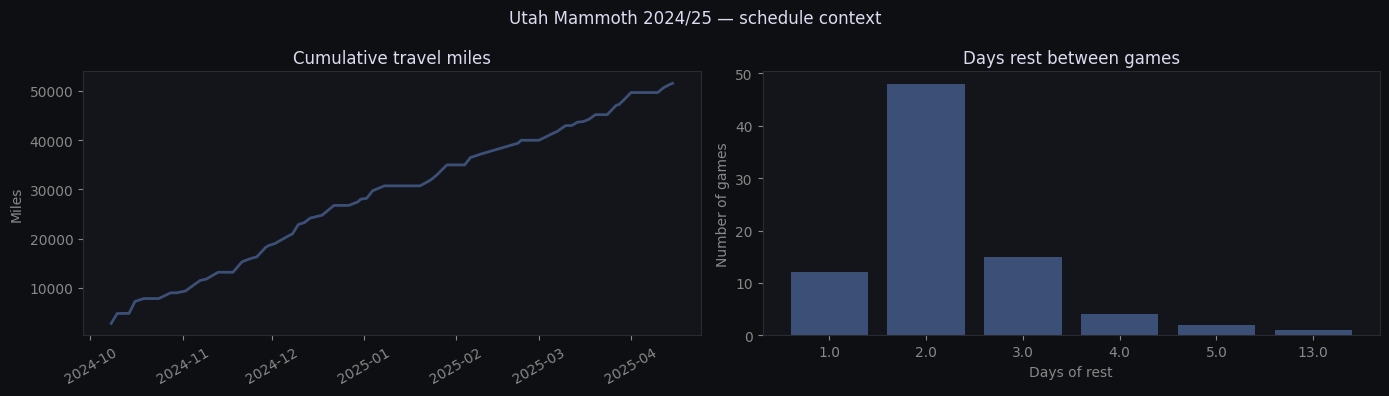

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Utah Mammoth 2024/25 — schedule context', color=LAVENDER)

axes[0].plot(schedule['date'], schedule['cumulative_road_miles'], color=NAVY, linewidth=2)
axes[0].set_title('Cumulative travel miles', color=LAVENDER)
axes[0].set_ylabel('Miles')
axes[0].tick_params(axis='x', rotation=30)

rest_counts = schedule['days_rest'].value_counts().sort_index().head(7)
axes[1].bar(rest_counts.index.astype(str), rest_counts.values, color=NAVY)
axes[1].set_title('Days rest between games', color=LAVENDER)
axes[1].set_xlabel('Days of rest')
axes[1].set_ylabel('Number of games')

plt.tight_layout()
plt.show()

---
## 5. Clayton Keller — fatigue signals across the season

We use Keller as the baseline — 81 games played, no injury gaps, veteran self-regulation. This establishes what fatigue-resistance looks like before we examine younger players.

In [7]:
KELLER_ID = 8479343

keller = get_player_game_log(KELLER_ID, SEASON_2425)
keller['gameDate'] = pd.to_datetime(keller['gameDate'])
keller['toi_min'] = keller['toi'].apply(
    lambda x: int(x.split(':')[0]) + int(x.split(':')[1])/60 if isinstance(x, str) else None
)
keller['toi_per_shift']   = (keller['toi_min'] / keller['shifts']).round(3)
keller['shots_per_shift'] = (keller['shots'] / keller['shifts']).round(3)

keller = keller.merge(
    schedule[['game_id','days_rest','is_back_to_back','travel_miles','road_trip_game_num']],
    left_on='gameId', right_on='game_id', how='left'
).sort_values('gameDate').reset_index(drop=True)

for col in ['points','shots','toi_min','toi_per_shift','shots_per_shift']:
    keller[f'{col}_rolling'] = keller[col].rolling(5, min_periods=2).mean().round(3)

print(f'{len(keller)} games merged')
keller[['gameDate','opponentAbbrev','points','toi_min','toi_per_shift',
        'shots_per_shift','days_rest','is_back_to_back']].head(10)

81 games merged


,gameDate,opponentAbbrev,points,toi_min,toi_per_shift,shots_per_shift,days_rest,is_back_to_back
0,2024-10-08,CHI,1,17.48,0.73,0.12,3.00,False
1,2024-10-10,NYI,2,20.10,0.77,0.12,2.00,False
2,2024-10-12,NYR,3,19.15,0.80,0.12,2.00,False
3,2024-10-14,NJD,0,16.98,0.81,0.14,2.00,False
4,2024-10-16,ANA,1,18.77,0.89,0.14,2.00,False
5,2024-10-19,BOS,1,21.32,0.89,0.08,3.00,False
6,2024-10-22,OTT,0,19.12,0.83,0.13,3.00,False
7,2024-10-24,COL,0,18.47,0.88,0.24,2.00,False
8,2024-10-26,LAK,1,21.77,0.84,0.12,2.00,False
9,2024-10-28,SJS,1,18.97,0.79,0.08,2.00,False


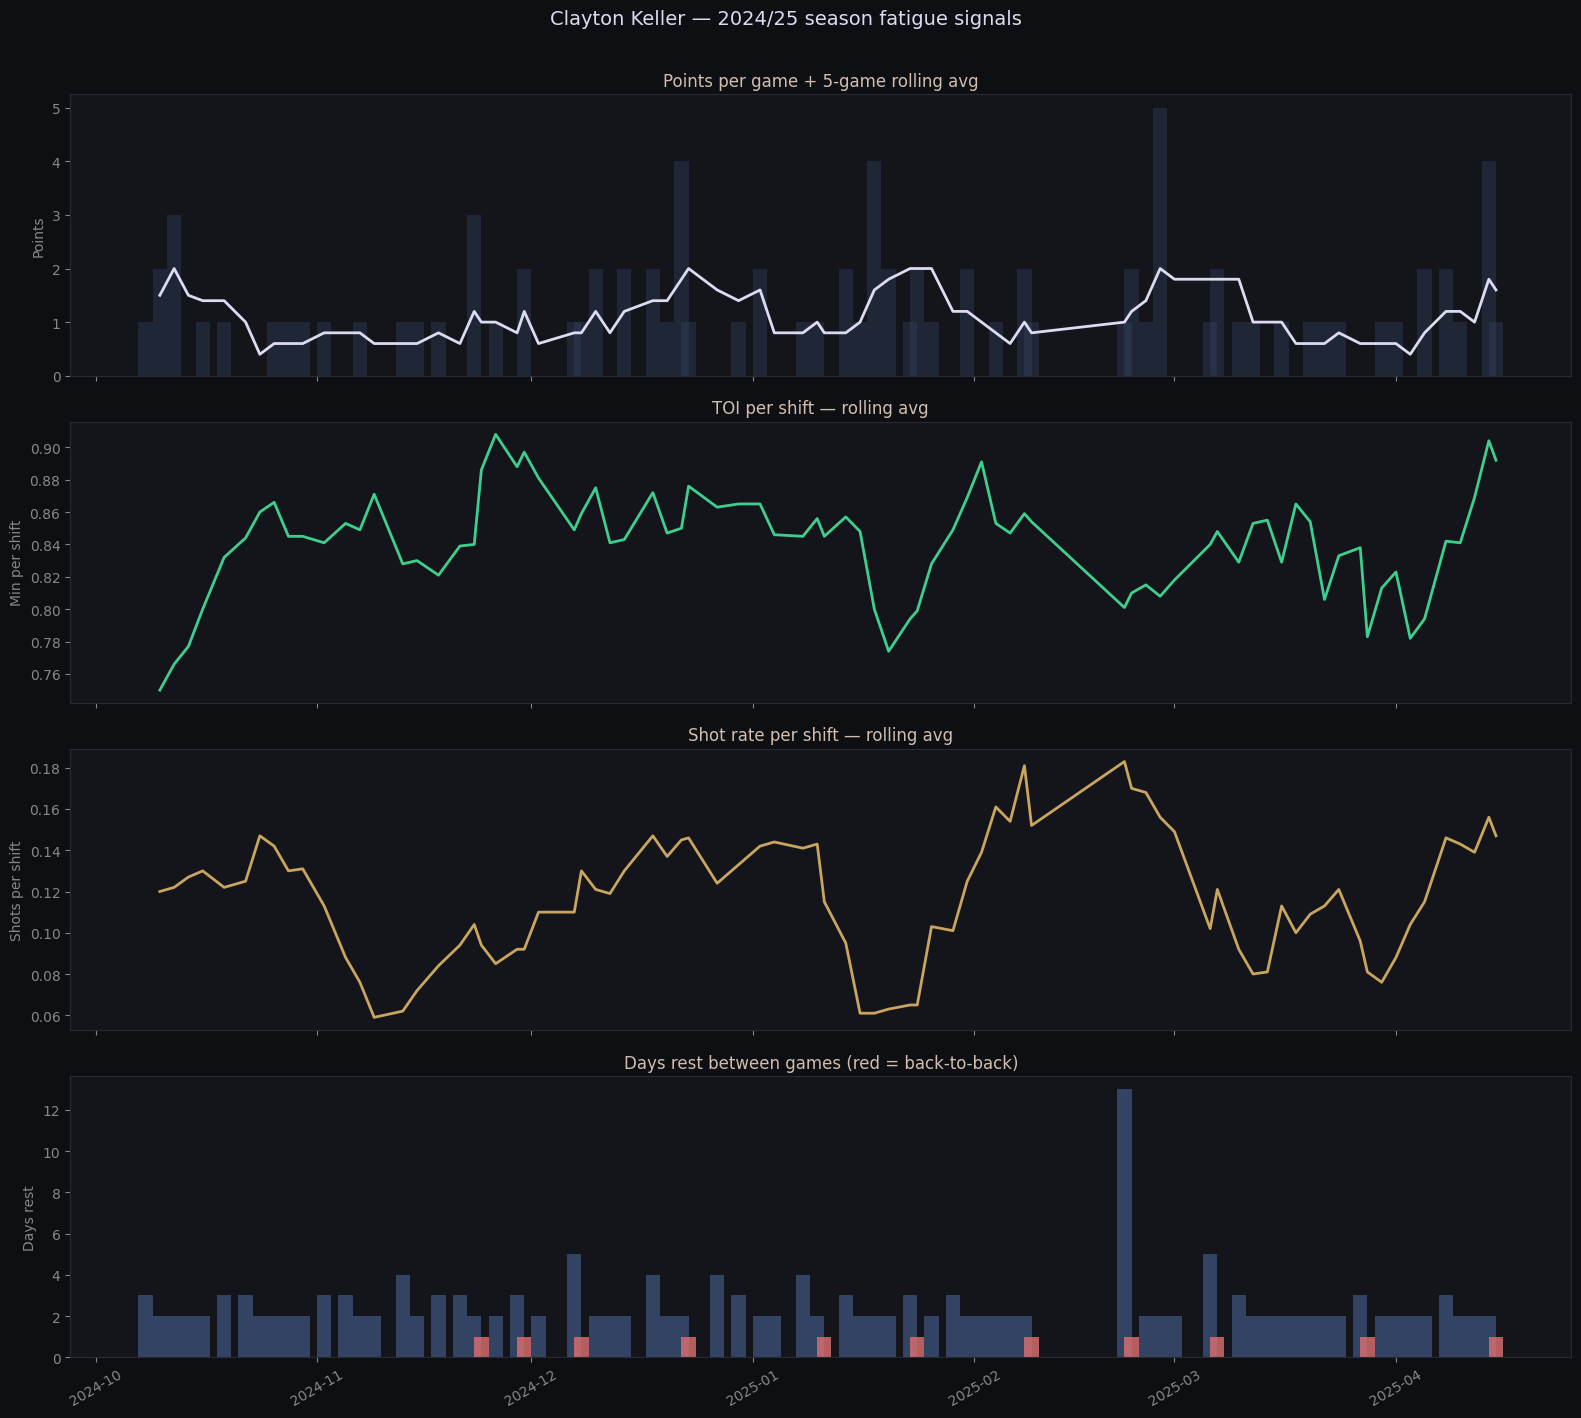

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
fig.suptitle('Clayton Keller — 2024/25 season fatigue signals', fontsize=14, color=LAVENDER, y=1.01)

axes[0].bar(keller['gameDate'], keller['points'], alpha=0.3, color=NAVY, width=2)
axes[0].plot(keller['gameDate'], keller['points_rolling'], color=LAVENDER, linewidth=2)
axes[0].set_ylabel('Points')
axes[0].set_title('Points per game + 5-game rolling avg', color=SAND)

axes[1].plot(keller['gameDate'], keller['toi_per_shift_rolling'], color=GREEN, linewidth=2)
axes[1].set_ylabel('Min per shift')
axes[1].set_title('TOI per shift — rolling avg', color=SAND)

axes[2].plot(keller['gameDate'], keller['shots_per_shift_rolling'], color=AMBER, linewidth=2)
axes[2].set_ylabel('Shots per shift')
axes[2].set_title('Shot rate per shift — rolling avg', color=SAND)

axes[3].bar(keller['gameDate'], keller['days_rest'].fillna(0),
            color=[RED if b else NAVY for b in keller['is_back_to_back']],
            width=2, alpha=0.8)
axes[3].set_ylabel('Days rest')
axes[3].set_title('Days rest between games (red = back-to-back)', color=SAND)
axes[3].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('keller_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Back-to-back vs. rested splits for Keller
b2b    = keller[keller['is_back_to_back'] == True]
rested = keller[keller['days_rest'] >= 2]

print('Back-to-back games:')
print(f'  Avg points:       {b2b["points"].mean():.2f}')
print(f'  Avg shots/shift:  {b2b["shots_per_shift"].mean():.3f}')
print(f'  Games:            {len(b2b)}')
print()
print('Well-rested games (2+ days rest):')
print(f'  Avg points:       {rested["points"].mean():.2f}')
print(f'  Avg shots/shift:  {rested["shots_per_shift"].mean():.3f}')
print(f'  Games:            {len(rested)}')

Back-to-back games:
  Avg points:       1.09
  Avg shots/shift:  0.088
  Games:            11

Well-rested games (2+ days rest):
  Avg points:       1.11
  Avg shots/shift:  0.122
  Games:            70


---
## 6. Back-to-back splits — full Utah roster

In [10]:
# Pull stats from NHL stats API for all Utah skaters
def get_uta_report(report, season=SEASON_2425):
    resp = requests.get(
        f'https://api.nhle.com/stats/rest/en/skater/{report}',
        params={'limit':100, 'cayenneExp': f"seasonId={season} and gameTypeId=2 and teamAbbrevs='UTA'"}
    )
    return pd.DataFrame(resp.json()['data'])

from functools import reduce

realtime     = get_uta_report('realtime')
timeonice    = get_uta_report('timeonice')
scoringrates = get_uta_report('scoringRates')
possessions  = get_uta_report('puckPossessions')

dfs = [
    realtime[['playerId','skaterFullName','gamesPlayed','hits','takeaways',
               'giveaways','blockedShots','timeOnIcePerGame']],
    timeonice[['playerId','shiftsPerGame','timeOnIcePerShift']],
    scoringrates[['playerId','pointsPer605v5','goalsPer605v5','satPct','satRelative5v5']],
    possessions[['playerId','offensiveZoneStartPct','usatPct']],
]

uta_combined = reduce(lambda l, r: l.merge(r, on='playerId', how='left'), dfs)
print(f'{len(uta_combined)} Utah players, {len(uta_combined.columns)} columns')
uta_combined.sort_values('pointsPer605v5', ascending=False).head(10)

24 Utah players, 16 columns


,playerId,skaterFullName,gamesPlayed,hits,takeaways,giveaways,blockedShots,timeOnIcePerGame,shiftsPerGame,timeOnIcePerShift,pointsPer605v5,goalsPer605v5,satPct,satRelative5v5,offensiveZoneStartPct,usatPct
17,8479343,Clayton Keller,81,11,27,79,30,1147.08,22.78,50.36,2.31,0.72,0.53,0.01,0.42,0.54
0,8483431,Logan Cooley,75,63,24,66,32,1071.68,22.33,47.99,2.31,1.07,0.50,-0.04,0.44,0.51
4,8479619,Michael Carcone,53,48,6,38,11,685.98,16.28,42.13,1.83,0.76,0.54,0.01,0.35,0.54
8,8477951,Nick Schmaltz,82,14,31,93,45,1115.29,22.57,49.41,1.79,0.58,0.53,0.01,0.40,0.54
2,8482699,Dylan Guenther,70,53,18,55,42,1019.82,20.64,49.40,1.72,0.76,0.52,-0.01,0.44,0.54
19,8480849,Barrett Hayton,82,31,16,46,44,966.08,22.02,43.86,1.52,0.64,0.57,0.05,0.38,0.58
11,8482659,Josh Doan,51,45,10,25,14,811.11,19.02,42.65,1.50,0.40,0.57,0.05,0.35,0.57
20,8478831,Kevin Stenlund,82,50,16,50,64,861.06,21.74,39.60,1.49,0.65,0.49,-0.05,0.27,0.50
3,8480855,Jack McBain,82,291,16,63,50,814.37,19.98,40.77,1.46,0.70,0.50,-0.03,0.32,0.51
12,8477021,Alexander Kerfoot,81,59,30,78,67,915.20,21.59,42.39,1.43,0.56,0.53,0.00,0.31,0.54


In [11]:
def build_player_context(game_log):
    df = game_log.copy()
    df['gameDate'] = pd.to_datetime(df['gameDate'])
    df = df.sort_values('gameDate').reset_index(drop=True)
    df['toi_min']         = df['toi'].apply(lambda x: int(x.split(':')[0]) + int(x.split(':')[1])/60 if isinstance(x, str) else None)
    df['shots_per_shift'] = (df['shots'] / df['shifts']).round(3)
    df['toi_per_shift']   = (df['toi_min'] / df['shifts']).round(3)
    df['is_road']         = df['homeRoadFlag'] == 'R'
    df['days_rest']       = df['gameDate'].diff().dt.days
    df['is_back_to_back'] = df['days_rest'] == 1
    road_trip_num = []
    counter = 0
    for _, row in df.iterrows():
        counter = 0 if not row['is_road'] else counter + 1
        road_trip_num.append(counter)
    df['road_trip_game_num'] = road_trip_num
    return df

# Pull game logs and compute back-to-back splits for all Utah skaters
b2b_results = []

for _, player in uta_combined.iterrows():
    try:
        log = get_player_game_log(int(player['playerId']), SEASON_2425)
        if len(log) < 20: continue
        df = build_player_context(log)
        b2b    = df[df['is_back_to_back'] == True]
        rested = df[df['days_rest'] >= 2]
        if len(b2b) < 3: continue
        b2b_results.append({
            'player':           player['skaterFullName'],
            'games':            len(df),
            'b2b_games':        len(b2b),
            'pts_rested':       rested['points'].mean(),
            'pts_b2b':          b2b['points'].mean(),
            'pts_drop_pct':     (b2b['points'].mean() - rested['points'].mean()) / rested['points'].mean() * 100 if rested['points'].mean() > 0 else None,
            'shots_rested':     rested['shots_per_shift'].mean(),
            'shots_b2b':        b2b['shots_per_shift'].mean(),
            'shots_drop_pct':   (b2b['shots_per_shift'].mean() - rested['shots_per_shift'].mean()) / rested['shots_per_shift'].mean() * 100 if rested['shots_per_shift'].mean() > 0 else None,
        })
        print(f'  ✓ {player["skaterFullName"]}')
    except Exception as e:
        print(f'  ✗ {player["skaterFullName"]}: {e}')

roster_b2b = pd.DataFrame(b2b_results).sort_values('shots_drop_pct')
print(f'\n{len(roster_b2b)} players analysed')
roster_b2b[['player','pts_rested','pts_b2b','pts_drop_pct','shots_rested','shots_b2b','shots_drop_pct']].round(2)

  ✓ Logan Cooley
  ✓ Dylan Guenther
  ✓ Jack McBain
  ✓ Michael Carcone
  ✓ Ian Cole
  ✓ Michael Kesselring
  ✓ Sean Durzi
  ✓ Nick Schmaltz
  ✓ Lawson Crouse
  ✓ Josh Doan
  ✓ Alexander Kerfoot
  ✓ Nick DeSimone
  ✓ Mikhail Sergachev
  ✓ Matias Maccelli
  ✓ Clayton Keller
  ✓ Nick Bjugstad
  ✓ Barrett Hayton
  ✓ Kevin Stenlund
  ✓ Juuso Välimäki
  ✓ John Marino

20 players analysed


,player,pts_rested,pts_b2b,pts_drop_pct,shots_rested,shots_b2b,shots_drop_pct
15,Nick Bjugstad,0.35,0.00,-100.00,0.11,0.06,-47.20
8,Lawson Crouse,0.25,0.00,-100.00,0.08,0.05,-33.54
14,Clayton Keller,1.12,1.09,-2.24,0.12,0.09,-27.36
4,Ian Cole,0.22,0.08,-61.67,0.03,0.02,-21.44
2,Jack McBain,0.32,0.42,30.68,0.06,0.04,-20.70
6,Sean Durzi,0.36,0.25,-30.56,0.05,0.04,-19.88
1,Dylan Guenther,0.86,0.70,-19.02,0.14,0.11,-17.77
19,John Marino,0.38,0.60,58.18,0.03,0.03,-15.34
16,Barrett Hayton,0.55,0.50,-9.21,0.08,0.07,-14.50
13,Matias Maccelli,0.38,0.00,-100.00,0.09,0.08,-7.60


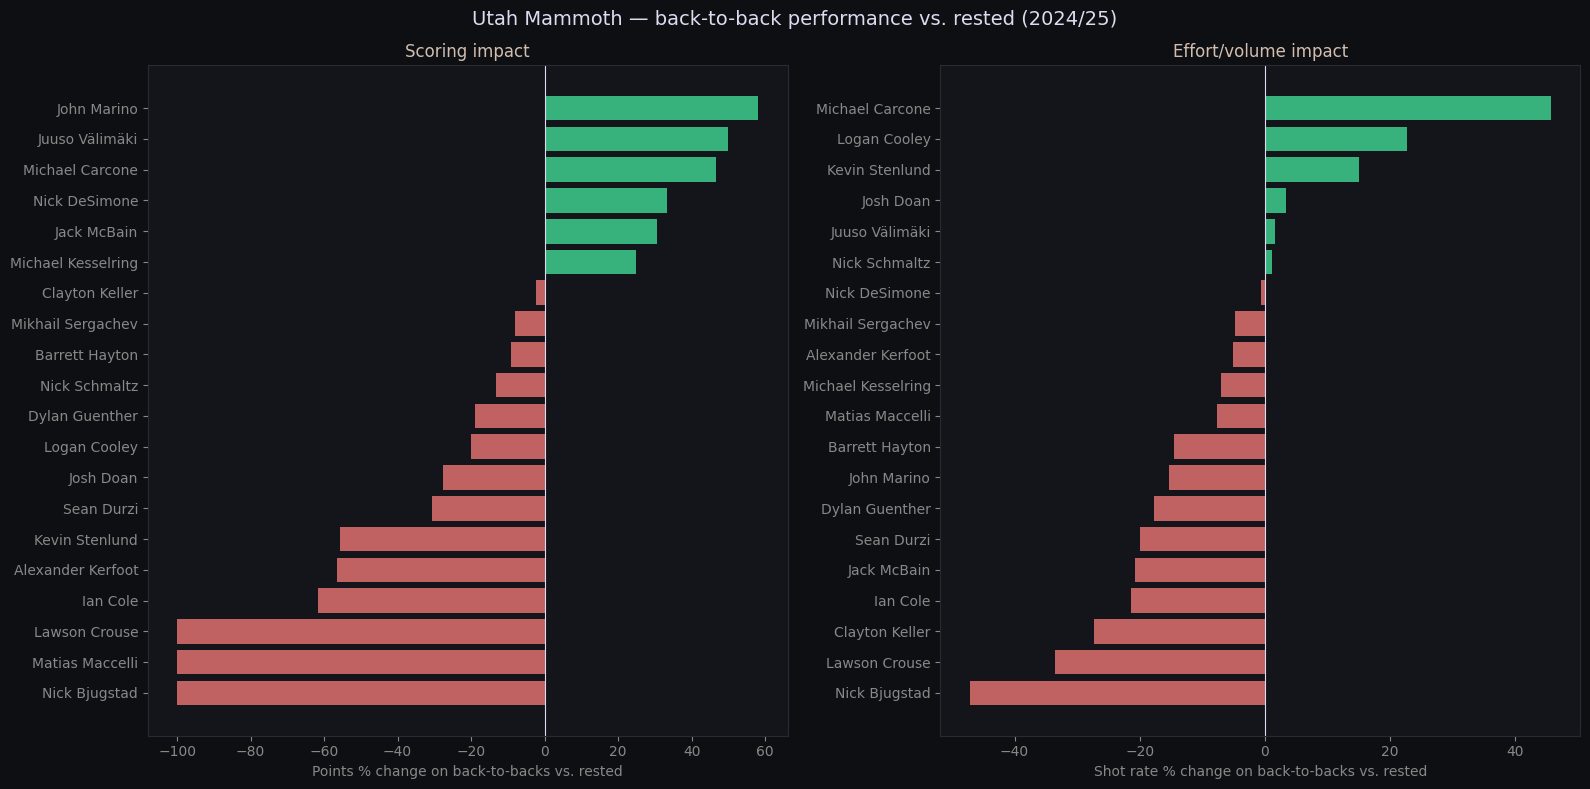

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Utah Mammoth — back-to-back performance vs. rested (2024/25)', fontsize=14, color=LAVENDER)

pts_sorted = roster_b2b.sort_values('pts_drop_pct')
colors_pts = [RED if x < 0 else GREEN for x in pts_sorted['pts_drop_pct']]
axes[0].barh(pts_sorted['player'], pts_sorted['pts_drop_pct'], color=colors_pts, alpha=0.85)
axes[0].axvline(0, color=LAVENDER, linewidth=0.8)
axes[0].set_xlabel('Points % change on back-to-backs vs. rested')
axes[0].set_title('Scoring impact', color=SAND)

shots_sorted = roster_b2b.sort_values('shots_drop_pct')
colors_shots = [RED if x < 0 else GREEN for x in shots_sorted['shots_drop_pct']]
axes[1].barh(shots_sorted['player'], shots_sorted['shots_drop_pct'], color=colors_shots, alpha=0.85)
axes[1].axvline(0, color=LAVENDER, linewidth=0.8)
axes[1].set_xlabel('Shot rate % change on back-to-backs vs. rested')
axes[1].set_title('Effort/volume impact', color=SAND)

plt.tight_layout()
plt.savefig('roster_b2b_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Road Trip Decay Index — full roster

In [13]:
road_results = []

for _, player in uta_combined.iterrows():
    try:
        log = get_player_game_log(int(player['playerId']), SEASON_2425)
        if len(log) < 20: continue
        df = build_player_context(log)
        home  = df[df['road_trip_game_num'] == 0]
        fresh = df[df['road_trip_game_num'] == 1]
        deep  = df[df['road_trip_game_num'] >= 3]
        if len(deep) < 3: continue
        road_results.append({
            'player':           player['skaterFullName'],
            'games':            len(df),
            'home_pts':         home['points'].mean(),
            'road_fresh_pts':   fresh['points'].mean(),
            'road_deep_pts':    deep['points'].mean(),
            'pts_decay':        deep['points'].mean() - fresh['points'].mean(),
            'deep_games':       len(deep),
        })
        print(f'  ✓ {player["skaterFullName"]} ({len(deep)} deep road games)')
    except Exception as e:
        print(f'  ✗ {player["skaterFullName"]}: {e}')

road_df = pd.DataFrame(road_results).sort_values('pts_decay')
print(f'\n{len(road_df)} players with enough road trip data')
road_df[['player','home_pts','road_fresh_pts','road_deep_pts','pts_decay','deep_games']].round(3)

  ✓ Logan Cooley (12 deep road games)
  ✓ Dylan Guenther (13 deep road games)
  ✓ Jack McBain (14 deep road games)
  ✓ Michael Carcone (9 deep road games)
  ✓ Ian Cole (14 deep road games)
  ✓ Michael Kesselring (14 deep road games)
  ✓ Sean Durzi (5 deep road games)
  ✓ Nick Schmaltz (14 deep road games)
  ✓ Lawson Crouse (14 deep road games)
  ✓ Josh Doan (8 deep road games)
  ✓ Alexander Kerfoot (14 deep road games)
  ✓ Nick DeSimone (3 deep road games)
  ✓ Mikhail Sergachev (13 deep road games)
  ✓ Matias Maccelli (8 deep road games)
  ✓ Clayton Keller (13 deep road games)
  ✓ Nick Bjugstad (13 deep road games)
  ✓ Barrett Hayton (14 deep road games)
  ✓ Kevin Stenlund (14 deep road games)
  ✓ Juuso Välimäki (7 deep road games)
  ✓ John Marino (5 deep road games)

20 players with enough road trip data


,player,home_pts,road_fresh_pts,road_deep_pts,pts_decay,deep_games
0,Logan Cooley,0.84,1.07,0.58,-0.49,12
17,Kevin Stenlund,0.37,0.33,0.14,-0.19,14
15,Nick Bjugstad,0.34,0.33,0.15,-0.18,13
10,Alexander Kerfoot,0.23,0.53,0.36,-0.18,14
5,Michael Kesselring,0.29,0.53,0.36,-0.18,14
1,Dylan Guenther,0.81,1.00,0.85,-0.15,13
9,Josh Doan,0.39,0.50,0.38,-0.12,8
14,Clayton Keller,1.20,0.73,0.61,-0.12,13
8,Lawson Crouse,0.20,0.40,0.29,-0.11,14
16,Barrett Hayton,0.58,0.60,0.50,-0.10,14


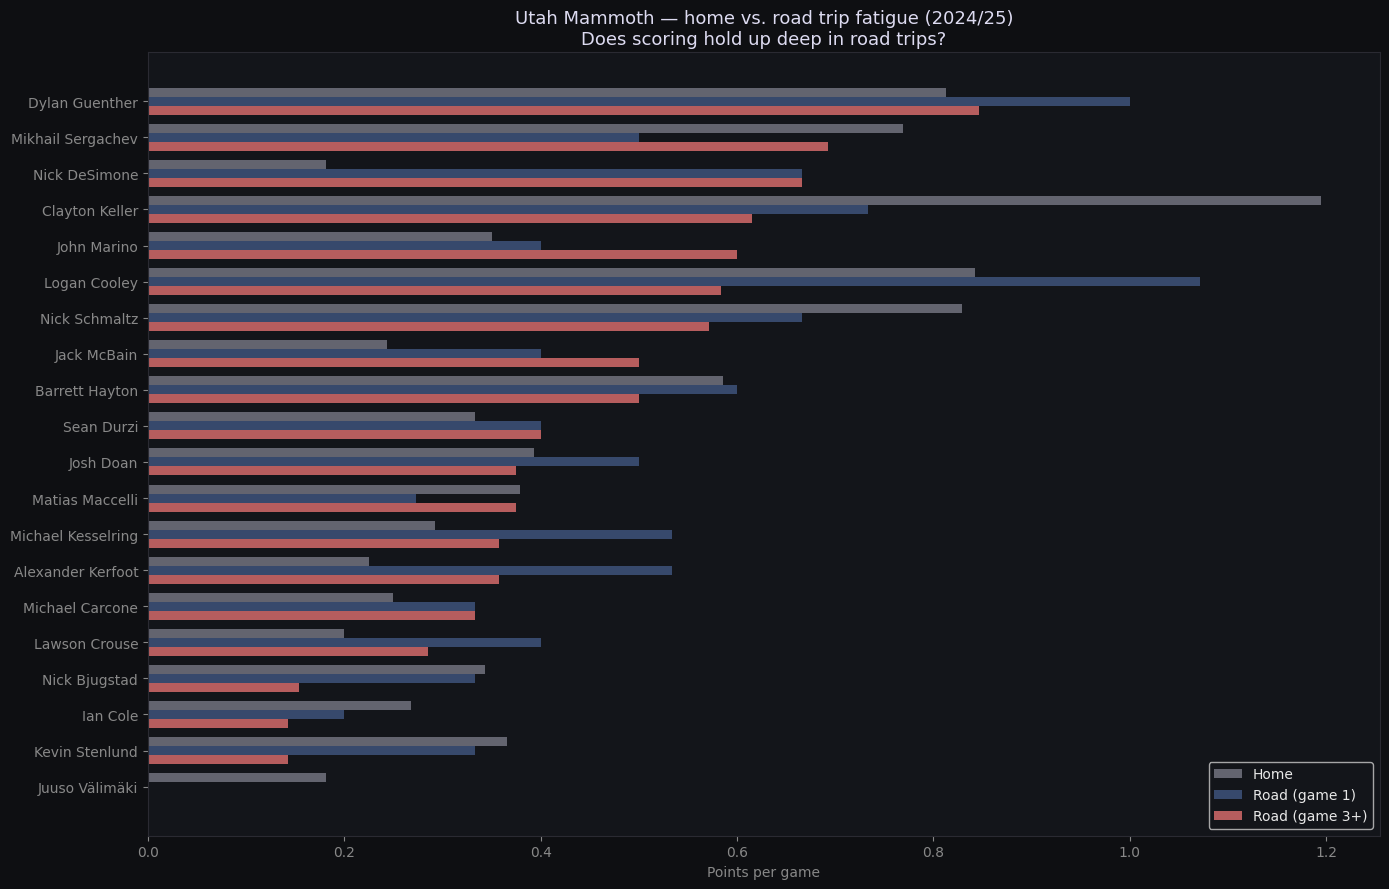

In [14]:
fig, ax = plt.subplots(figsize=(14, 9))
ax.set_facecolor('#13151a')

road_plot = road_df.sort_values('road_deep_pts', ascending=True)
players = road_plot['player']
y = range(len(players))
height = 0.25

ax.barh([i + height for i in y], road_plot['home_pts'],       height=height, label='Home',         color=LAVENDER, alpha=0.4)
ax.barh([i           for i in y], road_plot['road_fresh_pts'], height=height, label='Road (game 1)', color=NAVY,     alpha=0.9)
ax.barh([i - height  for i in y], road_plot['road_deep_pts'],  height=height, label='Road (game 3+)',color=RED,      alpha=0.8)

ax.set_yticks(list(y))
ax.set_yticklabels(players)
ax.set_xlabel('Points per game')
ax.set_title('Utah Mammoth — home vs. road trip fatigue (2024/25)\nDoes scoring hold up deep in road trips?',
             fontsize=13, color=LAVENDER)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('road_trip_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Logan Cooley — peer group comparison

Comparing Cooley's Road Trip Decay Index against 11 comparable young NHL players (ages 18–24, high-minute roles, 60+ games played).

In [15]:
def player_fatigue_profile(name, player_id, season):
    log = get_player_game_log(player_id, season)
    if len(log) < 20:
        print(f'  ✗ {name}: only {len(log)} games')
        return None
    df = build_player_context(log)
    home  = df[df['road_trip_game_num'] == 0]
    fresh = df[df['road_trip_game_num'] == 1]
    deep  = df[df['road_trip_game_num'] >= 3]
    b2b   = df[df['is_back_to_back'] == True]
    rested = df[df['days_rest'] >= 2]
    has_deep = len(deep) >= 3
    has_b2b  = len(b2b) >= 3
    print(f'  ✓ {name}: {len(df)} games, {len(deep)} deep road, {len(b2b)} b2b')
    return {
        'player':           name,
        'games':            len(df),
        'home_pts':         home['points'].mean(),
        'road_fresh_pts':   fresh['points'].mean(),
        'road_deep_pts':    deep['points'].mean() if has_deep else None,
        'pts_decay':        (deep['points'].mean() - fresh['points'].mean()) if has_deep else None,
        'b2b_pts':          b2b['points'].mean() if has_b2b else None,
        'rested_pts':       rested['points'].mean(),
        'deep_games':       len(deep),
        'b2b_games':        len(b2b),
    }

# Comparable young players — IDs confirmed via roster API
comparables = {
    'Logan Cooley':      8483431,
    'Connor Bedard':     8484144,
    'Leo Carlsson':      8484153,
    'Macklin Celebrini': 8484801,
    'Brock Faber':       8482122,
    'Marco Rossi':       8482079,
    'Shane Wright':      8483524,
    'Zach Benson':       8484145,
    'Tim Stutzle':       8482116,
    'Jack Hughes':       8481559,
    'Alexis Lafreniere': 8482078,
    'Matvei Michkov':    8484387,
}

print('Pulling 2024/25 comparable profiles...')
comp_results = []
for name, pid in comparables.items():
    profile = player_fatigue_profile(name, pid, SEASON_2425)
    if profile: comp_results.append(profile)

comp_df = pd.DataFrame(comp_results).sort_values('pts_decay')
print(f'\n{len(comp_df)} players in comparison group')
comp_df[['player','games','home_pts','road_fresh_pts','road_deep_pts','pts_decay','deep_games']].round(3)

Pulling 2024/25 comparable profiles...
  ✓ Logan Cooley: 75 games, 12 deep road, 10 b2b
  ✓ Connor Bedard: 82 games, 11 deep road, 12 b2b
  ✓ Leo Carlsson: 76 games, 10 deep road, 13 b2b
  ✓ Macklin Celebrini: 70 games, 16 deep road, 10 b2b
  ✓ Brock Faber: 78 games, 12 deep road, 11 b2b
  ✓ Marco Rossi: 82 games, 12 deep road, 12 b2b
  ✓ Shane Wright: 79 games, 19 deep road, 11 b2b
  ✓ Zach Benson: 75 games, 11 deep road, 11 b2b
  ✓ Tim Stutzle: 82 games, 13 deep road, 14 b2b
  ✓ Jack Hughes: 62 games, 8 deep road, 10 b2b
  ✓ Alexis Lafreniere: 82 games, 9 deep road, 11 b2b
  ✓ Matvei Michkov: 80 games, 10 deep road, 13 b2b

12 players in comparison group


,player,games,home_pts,road_fresh_pts,road_deep_pts,pts_decay,deep_games
9,Jack Hughes,62,1.14,1.41,0.62,-0.79,8
6,Shane Wright,79,0.51,0.92,0.37,-0.55,19
0,Logan Cooley,75,0.84,1.07,0.58,-0.49,12
7,Zach Benson,75,0.43,0.53,0.09,-0.44,11
3,Macklin Celebrini,70,0.94,1.10,0.69,-0.41,16
10,Alexis Lafreniere,82,1.27,0.75,0.44,-0.31,9
2,Leo Carlsson,76,0.70,0.56,0.40,-0.16,10
1,Connor Bedard,82,0.88,0.79,0.64,-0.15,11
8,Tim Stutzle,82,1.24,0.74,0.61,-0.12,13
5,Marco Rossi,82,0.68,0.77,0.75,-0.01,12


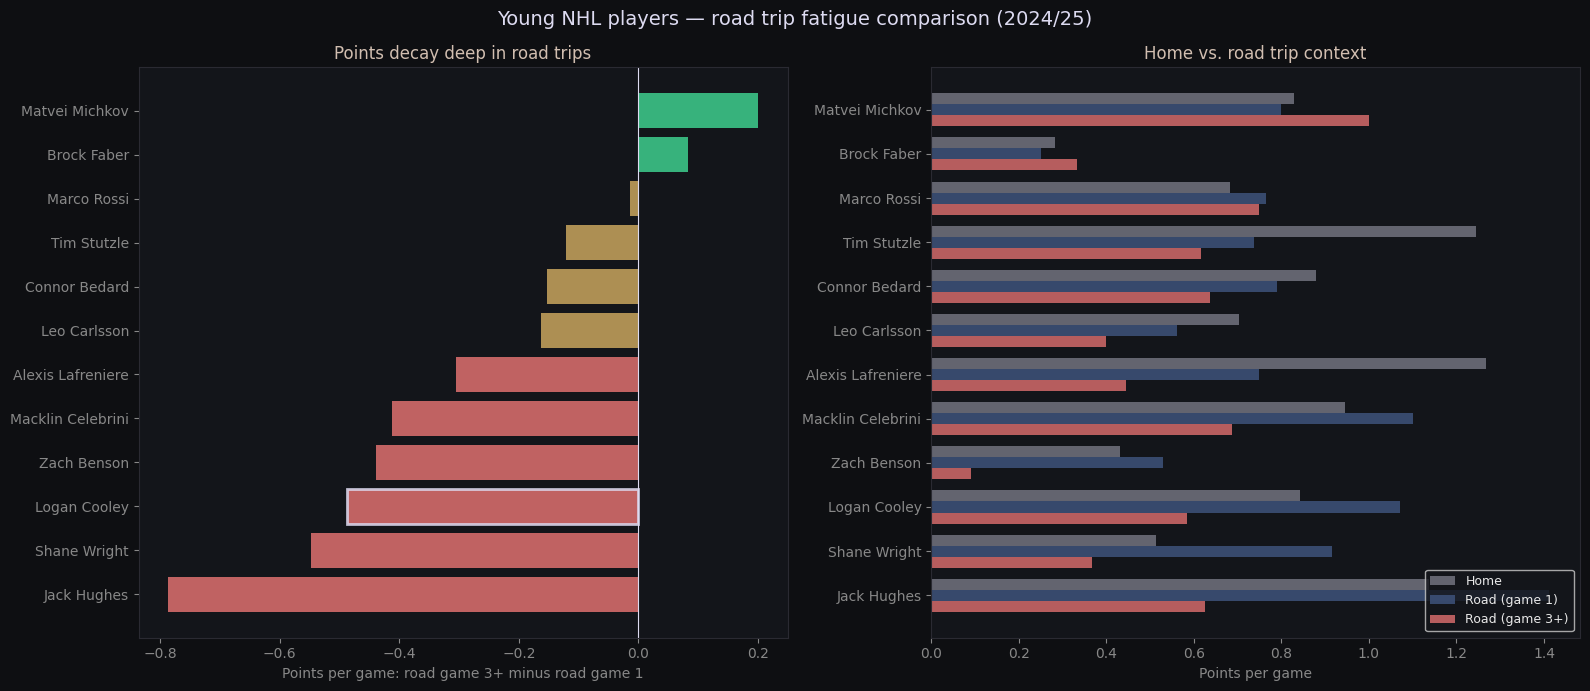

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Young NHL players — road trip fatigue comparison (2024/25)', fontsize=14, color=LAVENDER)

decay_sorted = comp_df.sort_values('pts_decay')
colors = [RED if x < -0.2 else AMBER if x < 0 else GREEN for x in decay_sorted['pts_decay']]
bars = axes[0].barh(decay_sorted['player'], decay_sorted['pts_decay'], color=colors, alpha=0.85)
axes[0].axvline(0, color=LAVENDER, linewidth=0.8)
axes[0].set_xlabel('Points per game: road game 3+ minus road game 1')
axes[0].set_title('Points decay deep in road trips', color=SAND)
# Highlight Cooley
for i, player in enumerate(decay_sorted['player']):
    if player == 'Logan Cooley':
        bars[i].set_edgecolor(LAVENDER)
        bars[i].set_linewidth(2)

x = range(len(comp_df.sort_values('pts_decay')))
w = 0.25
ps = comp_df.sort_values('pts_decay')
axes[1].barh([i + w for i in x], ps['home_pts'],       height=w, label='Home',         color=LAVENDER, alpha=0.4)
axes[1].barh([i     for i in x], ps['road_fresh_pts'], height=w, label='Road (game 1)', color=NAVY,     alpha=0.9)
axes[1].barh([i - w for i in x], ps['road_deep_pts'],  height=w, label='Road (game 3+)',color=RED,      alpha=0.8)
axes[1].set_yticks(list(x))
axes[1].set_yticklabels(ps['player'])
axes[1].set_xlabel('Points per game')
axes[1].set_title('Home vs. road trip context', color=SAND)
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('comparable_fatigue.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Logan Cooley — season arc (2024/25)

Splitting the season into thirds to see if his fatigue pattern improved across the year.

In [17]:
cooley_log = get_player_game_log(8483431, SEASON_2425)
cooley = build_player_context(cooley_log)

total = len(cooley)
third = total // 3
cooley['season_third'] = pd.cut(
    cooley.index,
    bins=[-1, third, third*2, total],
    labels=['Early (Oct-Dec)', 'Mid (Jan-Feb)', 'Late (Mar-Apr)']
)

print(f'Total games: {total}, third size: {third}')
print(cooley.groupby('season_third', observed=True)['gameDate'].agg(['min','max']))

thirds_results = []
for label in ['Early (Oct-Dec)', 'Mid (Jan-Feb)', 'Late (Mar-Apr)']:
    subset = cooley[cooley['season_third'] == label].copy().reset_index(drop=True)
    rtn = []
    counter = 0
    for _, row in subset.iterrows():
        counter = 0 if row['homeRoadFlag'] == 'H' else counter + 1
        rtn.append(counter)
    subset['road_trip_game_num'] = rtn
    home  = subset[subset['road_trip_game_num'] == 0]
    fresh = subset[subset['road_trip_game_num'] == 1]
    deep  = subset[subset['road_trip_game_num'] >= 3]
    thirds_results.append({
        'period':         label,
        'games':          len(subset),
        'home_pts':       home['points'].mean(),
        'road_fresh_pts': fresh['points'].mean(),
        'road_deep_pts':  deep['points'].mean() if len(deep) >= 2 else None,
        'pts_decay':      (deep['points'].mean() - fresh['points'].mean()) if len(deep) >= 2 else None,
        'deep_games':     len(deep),
    })

thirds_df = pd.DataFrame(thirds_results)
thirds_df[['period','games','home_pts','road_fresh_pts','road_deep_pts','pts_decay']].round(3)

Total games: 75, third size: 25
                       min        max
season_third                         
Early (Oct-Dec) 2024-10-08 2024-12-07
Mid (Jan-Feb)   2024-12-08 2025-02-23
Late (Mar-Apr)  2025-02-25 2025-04-15


,period,games,home_pts,road_fresh_pts,road_deep_pts,pts_decay
0,Early (Oct-Dec),26,0.55,1.33,0.67,-0.67
1,Mid (Jan-Feb),25,1.00,1.00,0.33,-0.67
2,Late (Mar-Apr),24,0.92,0.75,0.67,-0.08


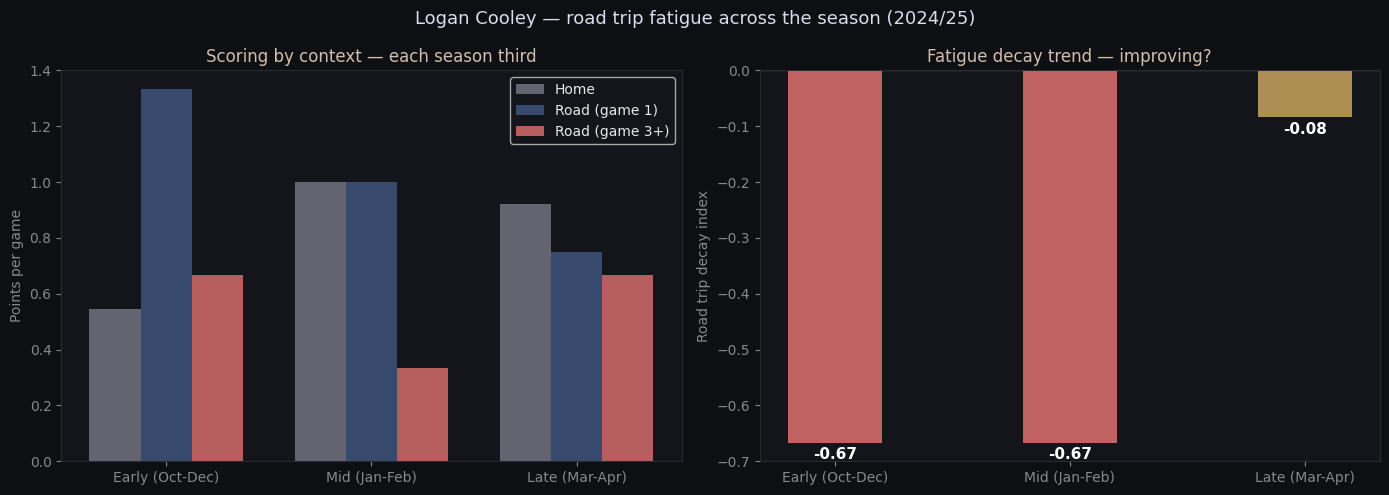

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logan Cooley — road trip fatigue across the season (2024/25)', fontsize=13, color=LAVENDER)

thirds = thirds_df['period']
x = range(len(thirds))
w = 0.25

axes[0].bar([i - w for i in x], thirds_df['home_pts'],       width=w, label='Home',         color=LAVENDER, alpha=0.4)
axes[0].bar([i     for i in x], thirds_df['road_fresh_pts'], width=w, label='Road (game 1)', color=NAVY,     alpha=0.9)
axes[0].bar([i + w for i in x], thirds_df['road_deep_pts'],  width=w, label='Road (game 3+)',color=RED,      alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(thirds)
axes[0].set_ylabel('Points per game')
axes[0].set_title('Scoring by context — each season third', color=SAND)
axes[0].legend()

decay_vals = thirds_df['pts_decay'].values
colors = [RED if v is not None and v < -0.2 else AMBER if v is not None and v < 0 else GREEN for v in decay_vals]
axes[1].bar(thirds, decay_vals, color=colors, alpha=0.85, width=0.4)
axes[1].axhline(0, color=LAVENDER, linewidth=0.8)
axes[1].set_ylabel('Road trip decay index')
axes[1].set_title('Fatigue decay trend — improving?', color=SAND)
for i, v in enumerate(decay_vals):
    if v is not None:
        axes[1].text(i, v - 0.03 if v < 0 else v + 0.01, f'{v:.2f}', ha='center', fontsize=11, fontweight='bold', color='white')

plt.tight_layout()
plt.savefig('cooley_season_thirds.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Year-over-year comparison — 2024/25 vs. 2025/26

In [19]:
# Build player ID lookup from 2025/26 roster
roster_new = get_roster(TEAM, SEASON_2526)

key_players = ['Cooley','Keller','Guenther','Schmaltz','Hayton',
               'Sergachev','Crouse','Stenlund','Kerfoot','McBain','Peterka','Weegar']

id_lookup = {}
for name in key_players:
    match = roster_new[roster_new['last_name'] == name]
    if not match.empty:
        pid  = match.iloc[0]['player_id']
        full = f"{match.iloc[0]['first_name']} {match.iloc[0]['last_name']}"
        id_lookup[full] = pid
        print(f'  ✓ {full}: {pid}')

print(f'\n{len(id_lookup)} players found')

  ✓ Logan Cooley: 8483431
  ✓ Clayton Keller: 8479343
  ✓ Dylan Guenther: 8482699
  ✓ Nick Schmaltz: 8477951
  ✓ Barrett Hayton: 8480849
  ✓ Mikhail Sergachev: 8479410
  ✓ Lawson Crouse: 8478474
  ✓ Kevin Stenlund: 8478831
  ✓ Alexander Kerfoot: 8477021
  ✓ Jack McBain: 8480855
  ✓ JJ Peterka: 8482175
  ✓ MacKenzie Weegar: 8477346

12 players found


In [20]:
def season_fatigue_profiles(id_lookup, season):
    results = []
    for name, pid in id_lookup.items():
        profile = player_fatigue_profile(name, pid, season)
        if profile: results.append(profile)
    return pd.DataFrame(results)

print('=== 2024/25 ===')
fatigue_2425 = season_fatigue_profiles(id_lookup, SEASON_2425)

print('\n=== 2025/26 ===')
fatigue_2526 = season_fatigue_profiles(id_lookup, SEASON_2526)

# Year-over-year comparison
comparison = fatigue_2425[['player','pts_decay']].merge(
    fatigue_2526[['player','pts_decay']], on='player', suffixes=('_2425','_2526')
)
comparison['decay_change'] = (comparison['pts_decay_2526'] - comparison['pts_decay_2425']).round(3)
comparison_sorted = comparison.sort_values('decay_change', ascending=False)
print()
comparison_sorted[['player','pts_decay_2425','pts_decay_2526','decay_change']].round(3)

=== 2024/25 ===
  ✓ Logan Cooley: 75 games, 12 deep road, 10 b2b
  ✓ Clayton Keller: 81 games, 13 deep road, 11 b2b
  ✓ Dylan Guenther: 70 games, 13 deep road, 10 b2b
  ✓ Nick Schmaltz: 82 games, 14 deep road, 12 b2b
  ✓ Barrett Hayton: 82 games, 14 deep road, 12 b2b
  ✓ Mikhail Sergachev: 77 games, 13 deep road, 11 b2b
  ✓ Lawson Crouse: 81 games, 14 deep road, 12 b2b
  ✓ Kevin Stenlund: 82 games, 14 deep road, 12 b2b
  ✓ Alexander Kerfoot: 81 games, 14 deep road, 12 b2b
  ✓ Jack McBain: 82 games, 14 deep road, 12 b2b
  ✓ JJ Peterka: 77 games, 12 deep road, 13 b2b
  ✓ MacKenzie Weegar: 81 games, 11 deep road, 10 b2b

=== 2025/26 ===
  ✓ Logan Cooley: 54 games, 12 deep road, 8 b2b
  ✓ Clayton Keller: 82 games, 17 deep road, 11 b2b
  ✓ Dylan Guenther: 79 games, 15 deep road, 10 b2b
  ✓ Nick Schmaltz: 82 games, 17 deep road, 11 b2b
  ✓ Barrett Hayton: 67 games, 12 deep road, 8 b2b
  ✓ Mikhail Sergachev: 78 games, 14 deep road, 10 b2b
  ✓ Lawson Crouse: 81 games, 16 deep road, 11 b2b
  ✓ 

,player,pts_decay_2425,pts_decay_2526,decay_change
7,Kevin Stenlund,-0.19,0.28,0.47
6,Lawson Crouse,-0.11,0.12,0.23
9,Jack McBain,0.10,0.25,0.15
8,Alexander Kerfoot,-0.18,-0.10,0.08
11,MacKenzie Weegar,-0.08,-0.05,0.03
0,Logan Cooley,-0.49,-0.53,-0.04
4,Barrett Hayton,-0.10,-0.21,-0.11
10,JJ Peterka,0.13,-0.04,-0.17
1,Clayton Keller,-0.12,-0.35,-0.23
3,Nick Schmaltz,-0.10,-0.35,-0.26


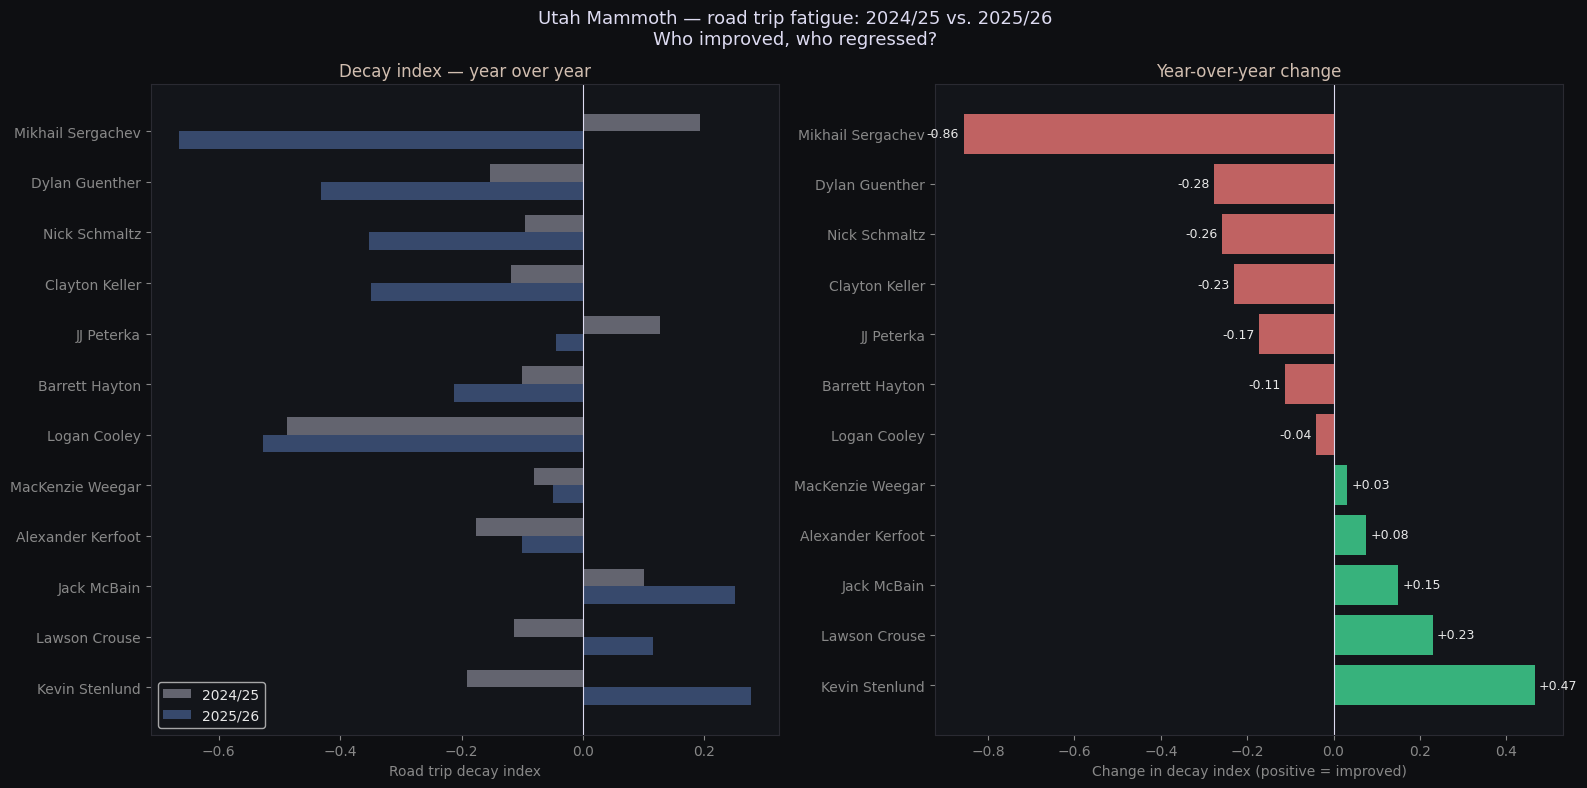

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Utah Mammoth — road trip fatigue: 2024/25 vs. 2025/26\nWho improved, who regressed?', fontsize=13, color=LAVENDER)

players = comparison_sorted['player']
y = range(len(players))
w = 0.35

axes[0].barh([i + w/2 for i in y], comparison_sorted['pts_decay_2425'], height=w, label='2024/25', color=LAVENDER, alpha=0.4)
axes[0].barh([i - w/2 for i in y], comparison_sorted['pts_decay_2526'], height=w, label='2025/26', color=NAVY,     alpha=0.9)
axes[0].axvline(0, color=LAVENDER, linewidth=0.8)
axes[0].set_yticks(list(y))
axes[0].set_yticklabels(players)
axes[0].set_xlabel('Road trip decay index')
axes[0].set_title('Decay index — year over year', color=SAND)
axes[0].legend()

colors = [GREEN if v > 0 else RED for v in comparison_sorted['decay_change']]
axes[1].barh(players, comparison_sorted['decay_change'], color=colors, alpha=0.85)
axes[1].axvline(0, color=LAVENDER, linewidth=0.8)
for i, (val, player) in enumerate(zip(comparison_sorted['decay_change'], players)):
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(val + (0.01 if val >= 0 else -0.01), i, f'{val:+.2f}', va='center', ha=ha, fontsize=9)
axes[1].set_xlabel('Change in decay index (positive = improved)')
axes[1].set_title('Year-over-year change', color=SAND)

plt.tight_layout()
plt.savefig('yoy_fatigue_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Logan Cooley — injury-adjusted 2025/26 analysis

Cooley missed approximately 9 weeks with injury (Dec 5 – Feb 4) plus the 3-week Winter Olympics break (Feb 4 – Feb 25). We split his season into three meaningful phases rather than calendar thirds.

In [22]:
cooley_2526 = get_player_game_log(8483431, SEASON_2526)
cooley_2526 = build_player_context(cooley_2526)

print(f'Total games: {len(cooley_2526)}')
print('\nLarge gaps (likely injury):')
print(cooley_2526[cooley_2526['days_rest'] > 10][['gameDate','days_rest','opponentAbbrev']])

Total games: 54

Large gaps (likely injury):
     gameDate  days_rest opponentAbbrev
29 2026-02-25      82.00            COL


In [23]:
# Split into meaningful phases around the injury
pre_injury  = cooley_2526[cooley_2526.index <= 28].copy()   # Oct 9 – Dec 5
post_return = cooley_2526[cooley_2526.index.isin(range(29, 37))].copy()  # First 8 games back
late_season = cooley_2526[cooley_2526.index >= 37].copy()   # Mar 12 – Apr 16

print(f'Pre-injury:   {len(pre_injury)} games  ({pre_injury["gameDate"].min().date()} – {pre_injury["gameDate"].max().date()})')
print(f'Post-return:  {len(post_return)} games ({post_return["gameDate"].min().date()} – {post_return["gameDate"].max().date()})')
print(f'Late season:  {len(late_season)} games  ({late_season["gameDate"].min().date()} – {late_season["gameDate"].max().date()})')

phases = {
    'Pre-injury (Oct–Dec)':    pre_injury,
    'Post-return (Feb–Mar)':   post_return,
    'Late season (Mar–Apr)':   late_season,
}

phase_results = []
for label, subset in phases.items():
    subset = subset.copy().reset_index(drop=True)
    rtn = []
    counter = 0
    for _, row in subset.iterrows():
        counter = 0 if row['homeRoadFlag'] == 'H' else counter + 1
        rtn.append(counter)
    subset['road_trip_game_num'] = rtn
    home  = subset[subset['road_trip_game_num'] == 0]
    fresh = subset[subset['road_trip_game_num'] == 1]
    deep  = subset[subset['road_trip_game_num'] >= 3]
    has_deep = len(deep) >= 2
    decay = round(deep['points'].mean() - fresh['points'].mean(), 2) if has_deep else None
    phase_results.append({
        'phase':          label,
        'games':          len(subset),
        'home_pts':       round(home['points'].mean(), 2),
        'road_fresh_pts': round(fresh['points'].mean(), 2),
        'road_deep_pts':  round(deep['points'].mean(), 2) if has_deep else None,
        'pts_decay':      decay,
        'deep_games':     len(deep),
    })
    print(f'{label}: decay = {decay}, deep games = {len(deep)}')

phases_df = pd.DataFrame(phase_results)
phases_df[['phase','games','home_pts','road_fresh_pts','road_deep_pts','pts_decay']].round(3)

Pre-injury:   29 games  (2025-10-09 – 2025-12-05)
Post-return:  8 games (2026-02-25 – 2026-03-10)
Late season:  17 games  (2026-03-12 – 2026-04-16)
Pre-injury (Oct–Dec): decay = -0.82, deep games = 8
Post-return (Feb–Mar): decay = -0.33, deep games = 3
Late season (Mar–Apr): decay = None, deep games = 1


,phase,games,home_pts,road_fresh_pts,road_deep_pts,pts_decay
0,Pre-injury (Oct–Dec),29,0.82,1.20,0.38,-0.82
1,Post-return (Feb–Mar),8,0.67,1.00,0.67,-0.33
2,Late season (Mar–Apr),17,0.64,1.00,NaN,NaN


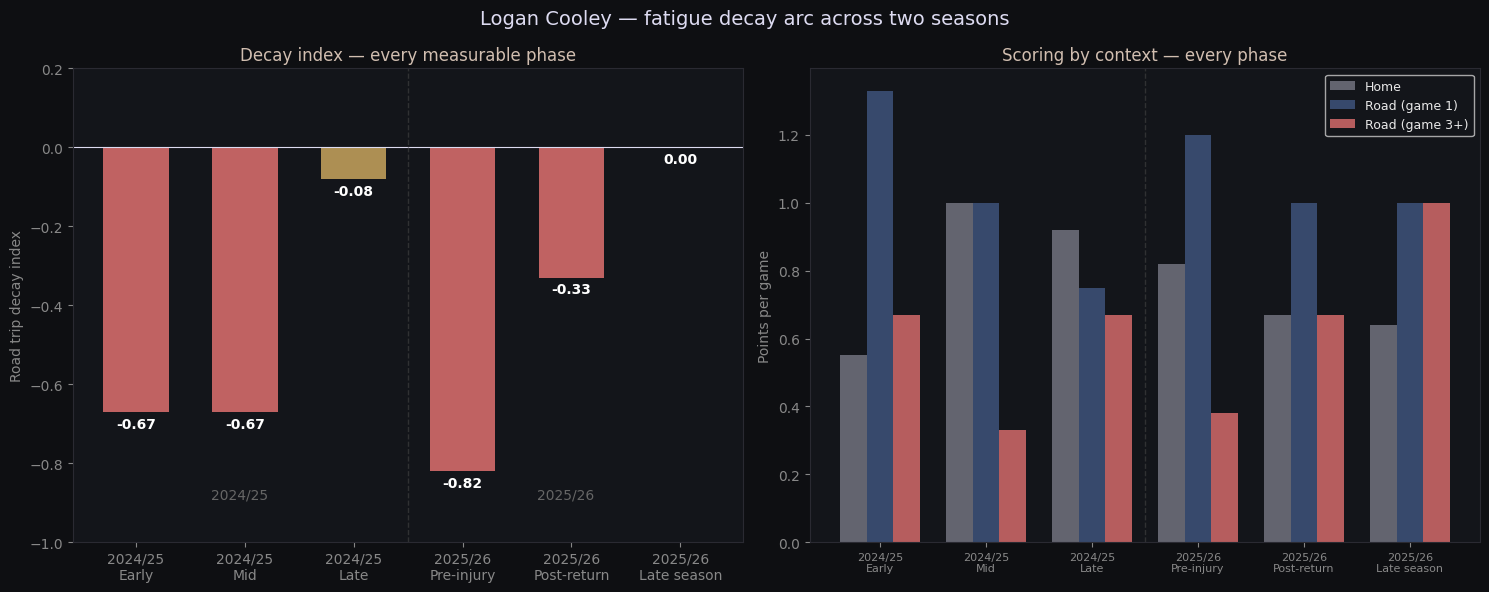

In [24]:
# Full two-season arc chart
phases_all = [
    ('2024/25\nEarly', -0.67), ('2024/25\nMid', -0.67), ('2024/25\nLate', -0.08),
    ('2025/26\nPre-injury', -0.82), ('2025/26\nPost-return', -0.33), ('2025/26\nLate season', 0.00),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Logan Cooley — fatigue decay arc across two seasons', fontsize=14, color=LAVENDER)

labels = [p[0] for p in phases_all]
values = [p[1] for p in phases_all]
colors = [RED if v < -0.2 else AMBER if v < 0 else GREEN for v in values]

axes[0].bar(labels, values, color=colors, alpha=0.85, width=0.6)
axes[0].axhline(0, color=LAVENDER, linewidth=0.8)
axes[0].axvline(2.5, color='#444', linewidth=1, linestyle='--', alpha=0.6)
axes[0].text(0.95, min(values)-0.07, '2024/25', fontsize=10, color='#666', ha='center')
axes[0].text(3.95, min(values)-0.07, '2025/26', fontsize=10, color='#666', ha='center')
axes[0].set_ylabel('Road trip decay index')
axes[0].set_title('Decay index — every measurable phase', color=SAND)
axes[0].set_ylim(-1.0, 0.2)
for i, v in enumerate(values):
    axes[0].text(i, v - 0.04, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold', color='white')

phases_pts = [
    ('2024/25\nEarly',       0.55, 1.33, 0.67),
    ('2024/25\nMid',         1.00, 1.00, 0.33),
    ('2024/25\nLate',        0.92, 0.75, 0.67),
    ('2025/26\nPre-injury',  0.82, 1.20, 0.38),
    ('2025/26\nPost-return', 0.67, 1.00, 0.67),
    ('2025/26\nLate season', 0.64, 1.00, 1.00),
]
x = range(len(phases_pts))
w = 0.25
axes[1].bar([i - w for i in x], [p[1] for p in phases_pts], width=w, label='Home',         color=LAVENDER, alpha=0.4)
axes[1].bar([i     for i in x], [p[2] for p in phases_pts], width=w, label='Road (game 1)', color=NAVY,     alpha=0.9)
axes[1].bar([i + w for i in x], [p[3] for p in phases_pts], width=w, label='Road (game 3+)',color=RED,      alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([p[0] for p in phases_pts], fontsize=8)
axes[1].axvline(2.5, color='#444', linewidth=1, linestyle='--', alpha=0.6)
axes[1].set_ylabel('Points per game')
axes[1].set_title('Scoring by context — every phase', color=SAND)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('cooley_full_arc.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Key findings & playoff implications

### Three things that matter heading into the 2026 playoffs

**1. Logan Cooley is playoff-ready.**  
His Road Trip Decay Index post-return (Feb 25 – Apr 16) is **0.00** — identical production in road game 1 and road game 3+. This is the best road-trip profile of his career across both seasons. The injury that cost Utah nine weeks of regular season appears to have functioned as an involuntary reset.

**2. The depth lines transformed.**  
Kevin Stenlund improved by **+0.47** year-over-year. Lawson Crouse by **+0.23**. Utah's third and fourth lines are dramatically more durable on the road than they were a season ago — which matters enormously in a seven-game playoff series.

**3. Watch Guenther and Keller in games 5–7.**  
Both regressed in road trip durability in 2025/26, likely from heavier workloads during the playoff push. They're still elite. The data says to manage their minutes carefully late in a deep road series.

---

### Methodology note

All data sourced from the NHL public API. No proprietary sources. Points are an imperfect proxy for physical load — NHL EDGE tracking data (speed, acceleration, distance per shift) would significantly strengthen these signals but remains largely inaccessible via the public API at this time.

Full dashboard with all 32 teams: [nhl-road-fatigue](https://github.com/yourusername/nhl-road-fatigue)